In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import joblib

#### Define Paths

In [4]:
processed_path = Path("../data/processed")
sequence_path = Path("../data/sequences")
scaler_path = Path("../data/scalers")

sequence_path.mkdir(parents=True, exist_ok=True)
scaler_path.mkdir(parents=True, exist_ok=True)

In [22]:
# Clear existing files in sequences folder

import shutil

shutil.rmtree(sequence_path)
sequence_path.mkdir(parents=True, exist_ok=True)

#### Hyperparamters

In [8]:
import sys
from pathlib import Path

_PROJECT_ROOT = Path("..").resolve()
if str(_PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(_PROJECT_ROOT))

from src.config import CONFIG

TRAIN_RATIO = 1.0 - float(CONFIG["test_split"])
WINDOW_SIZE = int(CONFIG["window_size"])

#### Train-test-split Function

In [11]:
def train_test_split_timeseries(df, train_ratio=0.8):

    df = df.sort_values("timestamp").reset_index(drop=True)

    split_idx = int(len(df) * train_ratio)

    train_df = df.iloc[:split_idx]
    test_df = df.iloc[split_idx:]

    return train_df, test_df

#### Sliding Window Function

In [14]:
def create_sequences(data, window_size):

    sequences = []

    for i in range(len(data) - window_size):
        sequences.append(data[i:i+window_size])

    return np.array(sequences)

#### Get Building Files

In [17]:
building_files = list(processed_path.glob("*.csv"))

print("Number of buildings:", len(building_files))

Number of buildings: 507


#### Main Processing Loop

In [26]:
for file in building_files:

    building_name = file.stem
    print(f"\nProcessing {building_name}")

    df = pd.read_csv(file)

    # ----- TRAIN TEST SPLIT -----
    train_df, test_df = train_test_split_timeseries(df, TRAIN_RATIO)

    # remove timestamp column
    train_features = train_df.drop(columns=["timestamp"])
    test_features = test_df.drop(columns=["timestamp"])

    # ----- SCALING -----
    scaler = StandardScaler()

    scaler.fit(train_features)

    train_scaled = scaler.transform(train_features)
    test_scaled = scaler.transform(test_features)

    joblib.dump(scaler, scaler_path / f"{building_name}_scaler.pkl")

    # ----- SLIDING WINDOWS -----
    X_train = create_sequences(train_scaled, WINDOW_SIZE)
    X_test = create_sequences(test_scaled, WINDOW_SIZE)

    # SAVE BOTH ARRAYS TO ONE FILE
    np.savez(
        sequence_path / f"{building_name}.npz",
        X_train=X_train,
        X_test=X_test,
        window_size=WINDOW_SIZE
    )

    print("Train shape:", X_train.shape)
    print("Test shape:", X_test.shape)


Processing Office_Abbey_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Abigail_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Alannah_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Aliyah_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Allyson_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Alyson_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Al_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Amelia_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Amelie_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Anastasia_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processing Office_Andrea_features
Train shape: (6849, 24, 17)
Test shape: (1695, 24, 17)

Processi

#### Visualization to ensure correct scaling

In [29]:
import numpy as np
import matplotlib.pyplot as plt

file = "../data/sequences/Office_Autumn_features.npz"

data = np.load(file)

X_train = data["X_train"]

In [31]:
print(X_train.shape)

(6849, 24, 17)


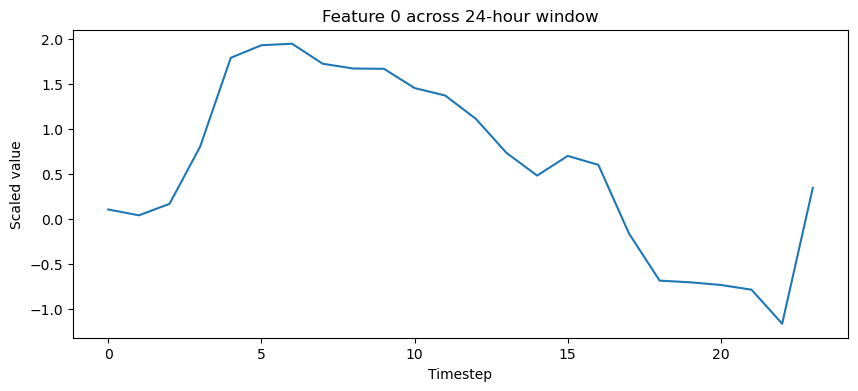

In [33]:
# Visualize one sequence

sequence = X_train[100]

plt.figure(figsize=(10,4))
plt.plot(sequence[:,0])
plt.title("Feature 0 across 24-hour window")
plt.xlabel("Timestep")
plt.ylabel("Scaled value")
plt.show()

We observe a smooth temporal structure, a clear rise -> peak -> decline -> night trough pattern, no random spikes, and values roughly between -1.2 and 2. 

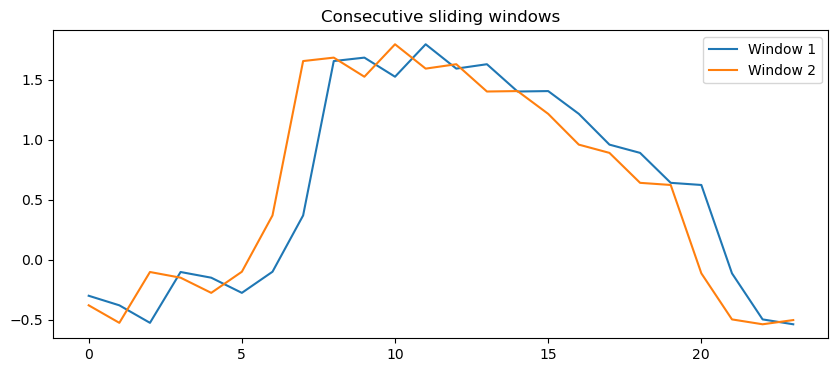

In [35]:
# Check sliding window continuity

plt.figure(figsize=(10,4))

plt.plot(X_train[0,:,0], label="Window 1")
plt.plot(X_train[1,:,0], label="Window 2")

plt.legend()
plt.title("Consecutive sliding windows")
plt.show()

We observe the two curves are almost identical, slightly shifted in time and follow the same shape. This confirms sliding window is correct.

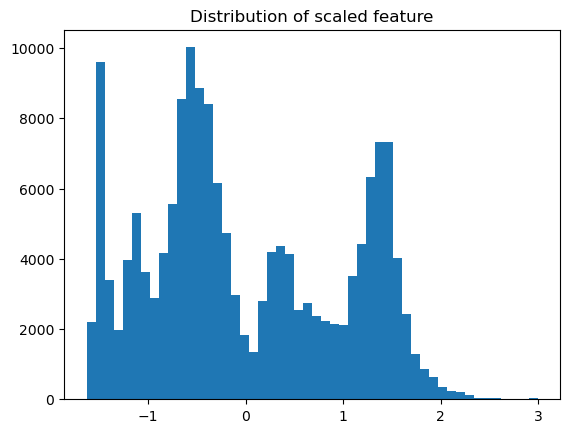

In [37]:
# Check scaling distribution 

plt.hist(X_train[:,:,0].flatten(), bins=50)
plt.title("Distribution of scaled feature")
plt.show()

We observe the center roughly near zero, spread approximately between -1.5 and 3, and a slightly multimodal distribution. Multiple peaks in the histogram are expected because energy consumption is different at different times of day and week. 

In [39]:
# Check for null 

np.isnan(X_train).sum()

0

In [47]:
# Check feature variance

np.var(X_train, axis=(0,1))

array([1.00086223, 0.99959226, 1.00249758, 0.99404195, 0.99980288,
       1.00019932, 0.99985918, 1.00010293, 1.00209328, 1.00095907,
       0.99974721, 0.99757374, 1.00046859, 1.00304231, 0.94376807,
       0.99983103, 1.00138783])

In [49]:
# Check dataset size

print(len(X_train))

6849


The implicit insight from these three plots is that this pipeline has preserved 3 critical properties:

Temporal Continuity: Confirmed by overlapping sliding windows

Structured Patterns: Daily energy cycles are visible

Stable Feature Scaling: Values centered near zero with reasonable variance